In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Loading the data
df = pd.read_csv("100_good_movies.csv")

In [3]:
df.head()

,rank,title,description,image,big_image,genre,thumbnail,rating,id,year,imdbid,imdb_link
0,1,The Shawshank Redemption,Two imprisoned men bond over a number of years...,https://m.media-amazon.com/images/M/MV5BMDFkYT...,https://m.media-amazon.com/images/M/MV5BMDFkYT...,['Drama'],https://m.media-amazon.com/images/M/MV5BMDFkYT...,9.3,top1,1994,tt0111161,https://www.imdb.com/title/tt0111161
1,2,The Godfather,The aging patriarch of an organized crime dyna...,https://m.media-amazon.com/images/M/MV5BM2MyNj...,https://m.media-amazon.com/images/M/MV5BM2MyNj...,"['Crime', 'Drama']",https://m.media-amazon.com/images/M/MV5BM2MyNj...,9.2,top2,1972,tt0068646,https://www.imdb.com/title/tt0068646
2,3,The Dark Knight,When the menace known as the Joker wreaks havo...,https://m.media-amazon.com/images/M/MV5BMTMxNT...,https://m.media-amazon.com/images/M/MV5BMTMxNT...,"['Action', 'Crime', 'Drama']",https://m.media-amazon.com/images/M/MV5BMTMxNT...,9.0,top3,2008,tt0468569,https://www.imdb.com/title/tt0468569
3,4,The Godfather Part II,The early life and career of Vito Corleone in ...,https://m.media-amazon.com/images/M/MV5BMWMwMG...,https://m.media-amazon.com/images/M/MV5BMWMwMG...,"['Crime', 'Drama']",https://m.media-amazon.com/images/M/MV5BMWMwMG...,9.0,top4,1974,tt0071562,https://www.imdb.com/title/tt0071562
4,5,12 Angry Men,The jury in a New York City murder trial is fr...,https://m.media-amazon.com/images/M/MV5BMWU4N2...,https://m.media-amazon.com/images/M/MV5BMWU4N2...,"['Crime', 'Drama']",https://m.media-amazon.com/images/M/MV5BMWU4N2...,9.0,top5,1957,tt0050083,https://www.imdb.com/title/tt0050083


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rank         100 non-null    int64  
 1   title        100 non-null    object 
 2   description  100 non-null    object 
 3   image        100 non-null    object 
 4   big_image    100 non-null    object 
 5   genre        100 non-null    object 
 6   thumbnail    100 non-null    object 
 7   rating       100 non-null    float64
 8   id           100 non-null    object 
 9   year         100 non-null    int64  
 10  imdbid       100 non-null    object 
 11  imdb_link    100 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 9.5+ KB


In [5]:
df.describe()

,rank,rating,year
count,100.000000,100.00000,100.000000
mean,50.500000,8.52200,1988.070000
std,29.011492,0.20869,23.069178
min,1.000000,8.30000,1931.000000
25%,25.750000,8.40000,1974.750000
50%,50.500000,8.50000,1994.000000
75%,75.250000,8.60000,2003.250000
max,100.000000,9.30000,2023.000000


In [6]:
# Basic statistics

# mean of numeric columns
print("Mean (numeric only)")
print(df.mean(numeric_only=True))

# Meadian
print("\nMedian (numeric only):")
print(df.median(numeric_only=True))

# Mode
print("\nMode (numeric only):")
print(df.mode())

# Standard deviation
print("\nStandard Deviation (numeric only):")
print(df.std(numeric_only=True))

# Standard deviation
print("\nStandard Deviation (numeric only):")
print(df.std(numeric_only=True))

Mean (numeric only)
rank        50.500
rating       8.522
year      1988.070
dtype: float64

Median (numeric only):
rank        50.5
rating       8.5
year      1994.0
dtype: float64

Mode (numeric only):
    rank                        title  \
0      1                 12 Angry Men   
1      2        2001: A Space Odyssey   
2      3                     3 Idiots   
3      4                        Alien   
4      5                       Aliens   
..   ...                          ...   
95    96                  Toy Story 3   
96    97                       WALL·E   
97    98                     Whiplash   
98    99  Witness for the Prosecution   
99   100                   Your Name.   

                                          description  \
0   12-year-old Mathilda is reluctantly taken in b...   
1   A German U-boat stalks the frigid waters of th...   
2   A Phoenix secretary embezzles $40,000 from her...   
3   A Polish Jewish musician struggles to survive ...   
4   A U.S. Army of

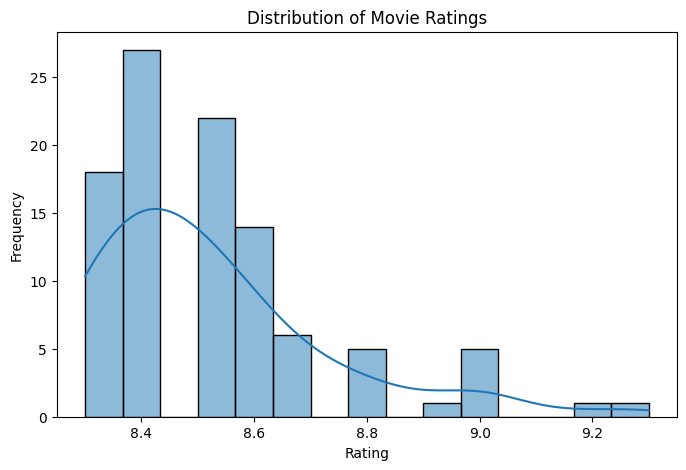

In [8]:

plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=15, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


In [10]:
rating_range = df['rating'].max() - df['rating'].min()
rating_var = df['rating'].var()
rating_std = df['rating'].std()

In [11]:
print(f"Range: {rating_range:.2f}")
print(f"Variance: {rating_var:.2f}")
print(f"Standard Deviation: {rating_std:.2f}")

Range: 1.00
Variance: 0.04
Standard Deviation: 0.21


In [14]:
# Example Events
# A: rating >= 8
# B: genre == 'Action'
A = df[df['rating'] >= 8]
B = df[df['genre'].str.contains('Action', case=False, na=False)]

In [15]:
P_A = len(A) / len(df)
P_B = len(B) / len(df)

In [17]:
print("\n- Probability Calculations -\n")
print(f"P(A) - Probability rating ≥ 8: {P_A:.2f}")
print(f"P(B) - Probability Action genre: {P_B:.2f}")


- Probability Calculations -

P(A) - Probability rating ≥ 8: 1.00
P(B) - Probability Action genre: 0.23


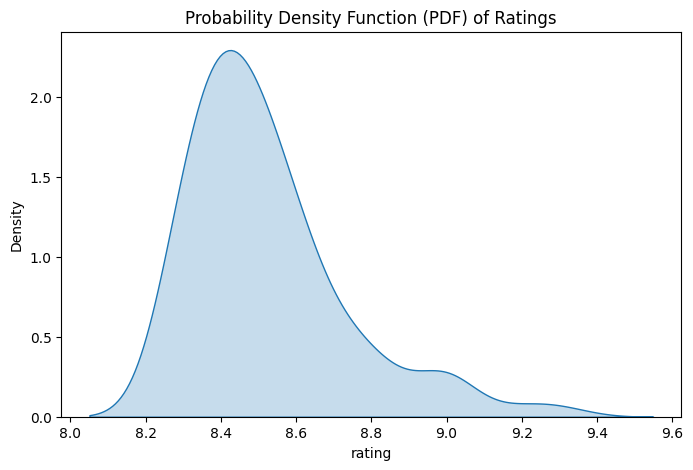

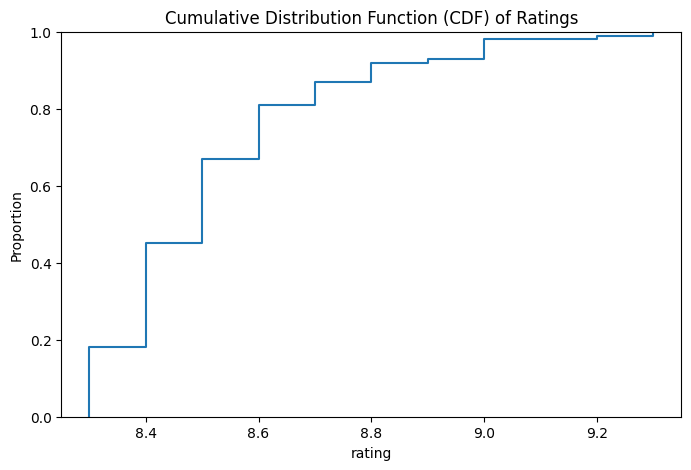

In [20]:
# Probability Distributions
plt.figure(figsize=(8,5))
sns.kdeplot(df['rating'], fill=True)
plt.title('Probability Density Function (PDF) of Ratings')
plt.show()


plt.figure(figsize=(8,5))
sns.ecdfplot(df['rating'])
plt.title('Cumulative Distribution Function (CDF) of Ratings')
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression

In [24]:
# Linear regression
X = df[['year']]
y = df['rating']

model = LinearRegression().fit(X,y)

In [26]:
print("\n- Regression Analysis -\n")
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R-squared: {model.score(X, y):.4f}")


- Regression Analysis -

Coefficient (slope): 0.0005
Intercept: 7.4977
R-squared: 0.0032


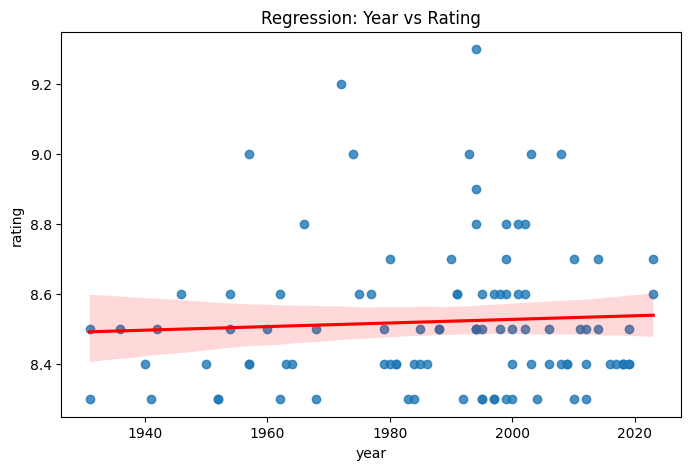

In [27]:
plt.figure(figsize=(8,5))
sns.regplot(x='year', y='rating', data=df, line_kws={'color':'red'})
plt.title('Regression: Year vs Rating')
plt.show()

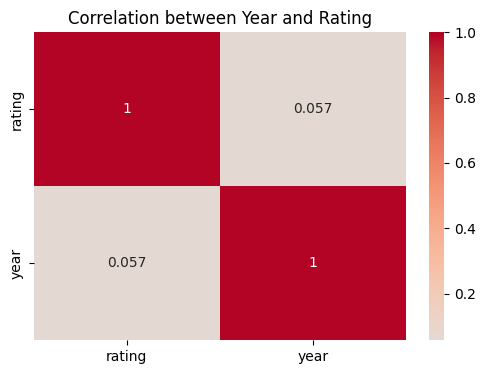

In [28]:
# Correlation matrix
plt.figure(figsize=(6,4))
sns.heatmap(df[['rating', 'year']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Year and Rating')
plt.show()
